In [1]:
model_name = "ResNet18-ragdoll"
model_file = "resnet18.mlir.v1"

import iree
import iree.compiler
import iree.runtime
import torch
import numpy as np
from torch import nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

image = torch.randn(1, 3, 224, 224)
image_np = image.detach().cpu().numpy()
image_transposed = torch.randn(1, 224, 224, 3)
image_np_transposed = image_transposed.detach().cpu().numpy()
model = models.resnet18().train(False)
model.load_state_dict({k: torch.ones_like(v) * 0.23421 for k, v in model.state_dict().items()})
output = model(image)
grad = torch.randn_like(output)
grad_np = grad.cpu().numpy()

BENCHMARK_REPEAT=111
df = pd.DataFrame()

In [2]:
!iree-compile {model_file}.heuristic{"-mulswap"} \
-o {model_file}.heuristic{"-mulswap"}.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

In [3]:

#!iree-compile recompute.mlir \
!iree-compile {model_file}.recompute \
-o {model_file}.recompute.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile {model_file}.storeall \
-o {model_file}.storeall.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile {model_file}.hybrid \
-o {model_file}.hybrid.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile {model_file}.heuristic \
-o {model_file}.heuristic.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86

#!iree-compile {model_file}.heuristic{"-mulswap"} \
#-o {model_file}.heuristic{"-mulswap"}.vmfb \
#--iree-hal-target-backends=cuda \
#--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
#--iree-hal-cuda-llvm-target-arch=sm_86

recompute = model_file+".recompute.vmfb"
storeall = model_file+".storeall.vmfb"
hybrid = model_file+".hybrid.vmfb"
heuristic = model_file+".heuristic.vmfb"
heuristic2 = model_file+".heuristic-mulswap.vmfb"

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable(recompute)
storeall_fb = load_executable(storeall)
hybrid_fb = load_executable(hybrid)
heuristic_fb = load_executable(heuristic)
heuristic2_fb = load_executable(heuristic2)

In [4]:
#f1 = timeit("recompute_fb.forward(image_np)") / BENCHMARK_REPEAT
f1 = timeit("recompute_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
b1 = timeit("recompute_fb.dforward(grad_np)") /  BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-Recompute")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  0.8845806618531545
ragdoll-opt1-gpu-backward in timeit:  3.970056286434064
       time      pass             item
0  0.884581   Forward  Nabla-Recompute
0  3.970056  Backward  Nabla-Recompute
0  4.854637      Full  Nabla-Recompute


In [5]:
f1 = timeit("storeall_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
b1 = timeit("storeall_fb.dforward(grad_np)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-Storeall")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  0.8892063797359262
ragdoll-opt1-gpu-forward in timeit:  3.9891429002153442
       time      pass             item
0  0.884581   Forward  Nabla-Recompute
0  3.970056  Backward  Nabla-Recompute
0  4.854637      Full  Nabla-Recompute
0  0.889206   Forward   Nabla-Storeall
0  3.989143  Backward   Nabla-Storeall
0  4.878349      Full   Nabla-Storeall


In [6]:
f1 = timeit("hybrid_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
b1 = timeit("hybrid_fb.dforward(grad_np)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-Hybrid")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  0.8058440120605467
ragdoll-opt1-gpu-forward in timeit:  3.8968979560577117
       time      pass             item
0  0.884581   Forward  Nabla-Recompute
0  3.970056  Backward  Nabla-Recompute
0  4.854637      Full  Nabla-Recompute
0  0.889206   Forward   Nabla-Storeall
0  3.989143  Backward   Nabla-Storeall
0  4.878349      Full   Nabla-Storeall
0  0.805844   Forward     Nabla-Hybrid
0  3.896898  Backward     Nabla-Hybrid
0  4.702742      Full     Nabla-Hybrid


In [7]:
f1 = timeit("heuristic_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
b1 = timeit("heuristic_fb.dforward(grad_np)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-Heuristic")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  0.6576068458558472
ragdoll-opt1-gpu-forward in timeit:  3.1703521343166225
       time      pass             item
0  0.884581   Forward  Nabla-Recompute
0  3.970056  Backward  Nabla-Recompute
0  4.854637      Full  Nabla-Recompute
0  0.889206   Forward   Nabla-Storeall
0  3.989143  Backward   Nabla-Storeall
0  4.878349      Full   Nabla-Storeall
0  0.805844   Forward     Nabla-Hybrid
0  3.896898  Backward     Nabla-Hybrid
0  4.702742      Full     Nabla-Hybrid
0  0.657607   Forward  Nabla-Heuristic
0  3.170352  Backward  Nabla-Heuristic
0  3.827959      Full  Nabla-Heuristic


In [8]:
f1 = timeit("heuristic2_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
b1 = timeit("heuristic2_fb.dforward(grad_np)") / BENCHMARK_REPEAT
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-Heuristic-Mulswap")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  0.653496681804861
ragdoll-opt1-gpu-forward in timeit:  3.146348976370719
       time      pass                     item
0  0.884581   Forward          Nabla-Recompute
0  3.970056  Backward          Nabla-Recompute
0  4.854637      Full          Nabla-Recompute
0  0.889206   Forward           Nabla-Storeall
0  3.989143  Backward           Nabla-Storeall
0  4.878349      Full           Nabla-Storeall
0  0.805844   Forward             Nabla-Hybrid
0  3.896898  Backward             Nabla-Hybrid
0  4.702742      Full             Nabla-Hybrid
0  0.657607   Forward          Nabla-Heuristic
0  3.170352  Backward          Nabla-Heuristic
0  3.827959      Full          Nabla-Heuristic
0  0.653497   Forward  Nabla-Heuristic-Mulswap
0  3.146349  Backward  Nabla-Heuristic-Mulswap
0  3.799846      Full  Nabla-Heuristic-Mulswap


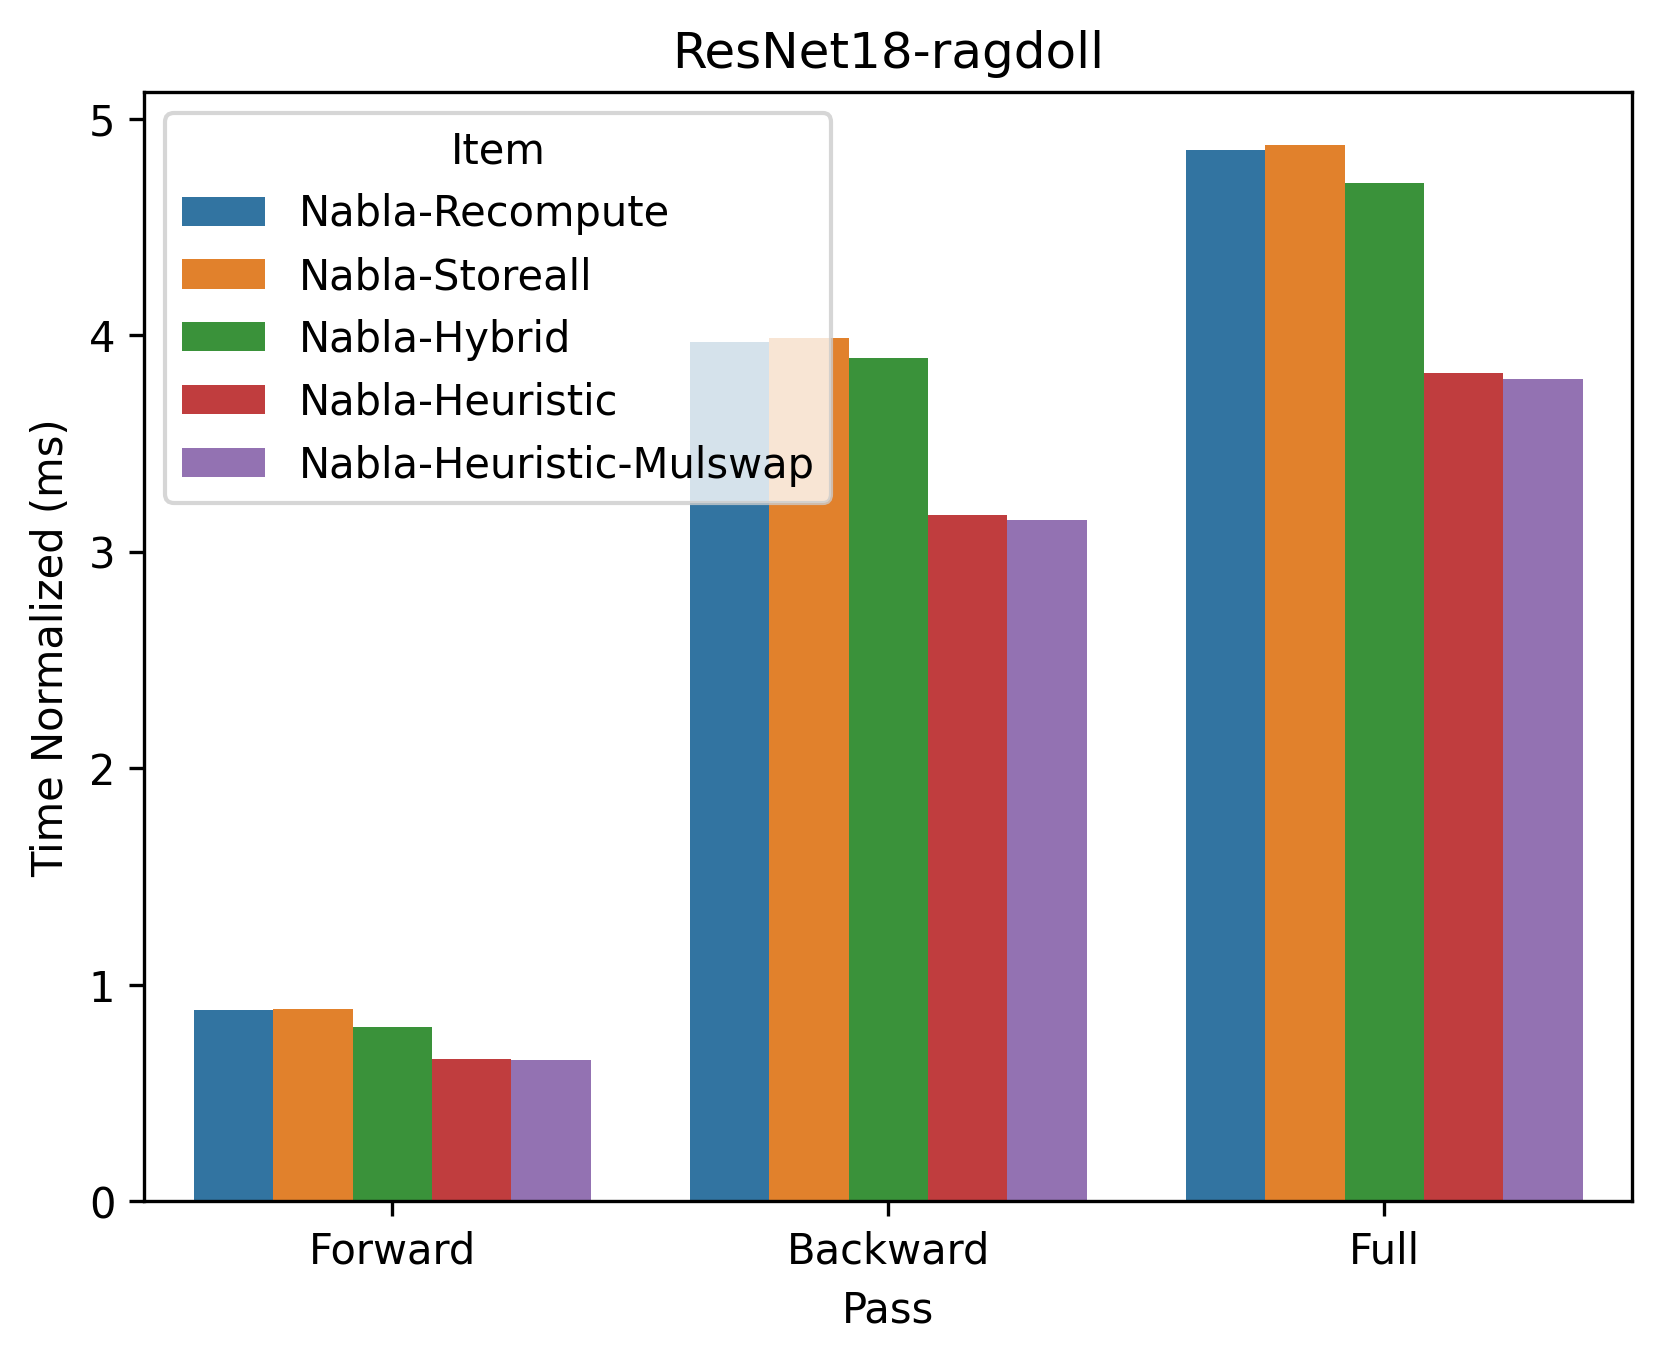

In [9]:
df.style.hide(axis="index")
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")